# Manual / visual inspection of crypt segmentation

Single-notebook workflow to **filter and visually inspect** crypt segmentations.

It:
- scans graphs + segmentations
- builds an in-memory table of per-organoid summary stats
- filters by timepoint, number of crypts, marker presence (organoid-wide or crypt-only), and future shape complexity
- plots organoids with nodes colored by markers and crypt regions highlighted

Backends:
- `plotly` (interactive)
- `mpl3d` (lightweight static 3D)
- `orthoprojs` (3-panel orthographic QC)

In [ ]:
# If you edit paths, re-run this cell and everything below.
import os, glob
import numpy as np
import pandas as pd

# Optional: widgets (nice UX, but notebook still works without them)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

import organograph
from organograph.graph.io import load_cell_graph
from organograph.graph.access import graph_get, graph_get_meta, graph_get_marker_bin

# Plotting (expects your backend-enabled plotting)
from organograph.plotting.graphs import *

# -----------------------
# CONFIG (edit these)
# -----------------------

GRAPHS_DIR = "../../NicoleData/20251201/graphs_preprocessed"
SEG_DIR    = "../../NicoleData/20251201/crypt_segmentations"

# Timepoints to consider (None -> auto-discover from GRAPHS_DIR)
TIMEPOINTS = ["day4p5"]  # or None

# Plotting backend: "plotly" | "mpl3d" | "orthoprojs"
BACKEND = "orthoprojs"

# Fixed view settings (recommended defaults)
VIEW = dict(azim=-135, elev=25, projection="orthographic")

NODE_SIZE = 5
EDGE_WIDTH = 1.0

# Crypt overlay style
CRYPT_OVERLAY_COLOR = None           # set to "#FFD700" to force single-color
CRYPT_OVERLAY_COLORSCALE = "Turbo"   # good separation: "Turbo", "Viridis", "Plasma", "Rainbow"
CRYPT_OVERLAY_ALPHA = 0.45
CRYPT_OVERLAY_SIZE_MULT = 1.7


# Marker definitions for coloring (edit to match your marker_names)
DEFAULT_MARKER_MAP = [
    {"marker": 0, "color": "#1f77b4", "name": "stem cell (LGR5+)"},
    {"marker": 2, "color": "#2ca02c", "name": "absorptive (AldoB+)"},
    {"marker": 3, "color": "#d62728", "name": "enterochromaffin (Serotonin+)"},
    {"marker": 4, "color": "#9467bd", "name": "paneth (Lysozyme+)"},
]

print("HAS_WIDGETS:", HAS_WIDGETS)

HAS_WIDGETS: True


## Utilities

In [18]:
def discover_timepoints(graphs_dir):
    if not os.path.isdir(graphs_dir):
        return []
    tps = []
    for name in sorted(os.listdir(graphs_dir)):
        p = os.path.join(graphs_dir, name)
        if os.path.isdir(p) and (os.path.exists(os.path.join(p, "index.csv")) or glob.glob(os.path.join(p, "*.gpickle"))):
            tps.append(name)
    return tps


def load_index_records(graphs_dir, timepoint):
    """Return DataFrame with at least: label_uid, graph_path (mesh_path optional)."""
    idx_csv = os.path.join(graphs_dir, timepoint, "index.csv")
    if os.path.exists(idx_csv):
        df = pd.read_csv(idx_csv)
        if "label_uid" not in df.columns or "graph_path" not in df.columns:
            raise ValueError(f"{idx_csv} must contain columns: label_uid, graph_path")
        df["timepoint"] = timepoint
        return df

    gpaths = sorted(glob.glob(os.path.join(graphs_dir, timepoint, "*.gpickle")))
    rows = [{"timepoint": timepoint, "label_uid": None, "mesh_path": None, "graph_path": g} for g in gpaths]
    return pd.DataFrame(rows)


def resolve_graph_path(graphs_dir, timepoint, label_uid, graph_path_from_index):
    """If the index path is stale, try {graphs_dir}/{timepoint}/{label_uid}.gpickle."""
    if isinstance(graph_path_from_index, str) and os.path.exists(graph_path_from_index):
        return graph_path_from_index
    if label_uid is None:
        return graph_path_from_index
    cand = os.path.join(graphs_dir, timepoint, f"{label_uid}.gpickle")
    return cand if os.path.exists(cand) else graph_path_from_index


def load_segmentation_npz(seg_path):
    """Load segmentation; return dict with crypt list + crypt_nodes set."""
    if not isinstance(seg_path, str) or (not os.path.exists(seg_path)):
        return None
    dat = np.load(seg_path, allow_pickle=True)
    crypts_ll = None
    if "crypts_ll" in dat.files:
        crypts_ll = dat["crypts_ll"]
    elif "crypts" in dat.files:
        crypts_ll = dat["crypts"]

    crypts_list = []
    crypt_nodes = set()
    if crypts_ll is not None:
        try:
            for c in crypts_ll:
                arr = np.asarray(c, dtype=int)
                crypts_list.append(arr)
                for u in arr.tolist():
                    crypt_nodes.add(int(u))
        except Exception:
            crypts_list = []
            crypt_nodes = set()

    return {
        "path": seg_path,
        "files": list(dat.files),
        "crypts_ll": crypts_list,
        "crypt_nodes": crypt_nodes,
        "n_crypts": len(crypts_list),
    }


def marker_presence(G, marker, nodes=None):
    """Return (has_marker, fraction_positive)."""
    try:
        v = graph_get_marker_bin(G, marker, nodes=nodes)
        return bool(np.any(v == 1)), float(np.mean(v == 1))
    except Exception:
        return False, 0.0


def get_shape_complexity_if_present(G):
    for key in ("shape_complexity", "complexity", "mesh_complexity"):
        if key in G.graph:
            try:
                return float(G.graph[key])
            except Exception:
                return G.graph[key]
    return np.nan

## Build inspection table

In [19]:
def build_inspection_table(graphs_dir, seg_dir, timepoints=None, verbose=True, max_items=None):
    if timepoints is None:
        timepoints = discover_timepoints(graphs_dir)

    rows_out = []
    n_seen = 0

    for tp in timepoints:
        df_idx = load_index_records(graphs_dir, tp)
        tp_seg_dir = os.path.join(seg_dir, tp)

        for _, rec in df_idx.iterrows():
            if max_items is not None and n_seen >= int(max_items):
                break

            label_uid = rec.get("label_uid", None)
            gpath0 = rec.get("graph_path", None)
            gpath = resolve_graph_path(graphs_dir, tp, label_uid, gpath0)

            if not isinstance(gpath, str) or (not os.path.exists(gpath)):
                continue

            try:
                G = load_cell_graph(gpath)
            except Exception:
                continue

            label_uid_g = G.graph.get("label_uid", None) or label_uid
            if label_uid_g is None:
                continue

            seg_path = os.path.join(tp_seg_dir, f"{label_uid_g}.npz")
            seg = load_segmentation_npz(seg_path)
            n_crypts = seg["n_crypts"] if seg is not None else 0

            try:
                mb = graph_get(G, "markers_bin", dtype=np.int64)
                n_markers = int(mb.shape[1]) if mb.ndim == 2 else None
            except Exception:
                n_markers = None

            rows_out.append({
                "timepoint": tp,
                "label_uid": label_uid_g,
                "graph_path": gpath,
                "mesh_path": rec.get("mesh_path", None),
                "seg_path": seg_path if os.path.exists(seg_path) else None,
                "has_seg": bool(os.path.exists(seg_path)),
                "n_nodes": int(G.number_of_nodes()),
                "n_edges": int(G.number_of_edges()),
                "n_crypts": int(n_crypts),
                "shape_complexity": get_shape_complexity_if_present(G),
                "has_marker_names": bool(G.graph.get("marker_names", None) is not None),
                "n_markers": n_markers,
            })
            n_seen += 1

        if max_items is not None and n_seen >= int(max_items):
            break

    df = pd.DataFrame(rows_out)
    if verbose:
        print(f"[inspect] built table with {len(df)} organoids")
    return df

df_inspect = build_inspection_table(GRAPHS_DIR, SEG_DIR, TIMEPOINTS, verbose=True)
df_inspect.head()

[inspect] built table with 310 organoids


,timepoint,label_uid,graph_path,mesh_path,seg_path,has_seg,n_nodes,n_edges,n_crypts,shape_complexity,has_marker_names,n_markers
0,day4p5,day4p5_B02_100,/home/fmoller/Projects/LearningOrganoids/organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,../../NicoleData/20251201/crypt_segmentations/...,True,264,786,2,NaN,True,7
1,day4p5,day4p5_B02_101,/home/fmoller/Projects/LearningOrganoids/organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,../../NicoleData/20251201/crypt_segmentations/...,True,63,183,2,NaN,True,7
2,day4p5,day4p5_B02_11,/home/fmoller/Projects/LearningOrganoids/organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,../../NicoleData/20251201/crypt_segmentations/...,True,274,816,2,NaN,True,7
3,day4p5,day4p5_B02_110,/home/fmoller/Projects/LearningOrganoids/organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,../../NicoleData/20251201/crypt_segmentations/...,True,426,1272,2,NaN,True,7
4,day4p5,day4p5_B02_112,/home/fmoller/Projects/LearningOrganoids/organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,../../NicoleData/20251201/crypt_segmentations/...,True,2413,7126,6,NaN,True,7


## Filtering

In [20]:
def filter_table(df, *, timepoint=None, n_crypts_min=None, n_crypts_max=None, require_seg=True):
    out = df.copy()
    if timepoint is not None:
        out = out[out["timepoint"] == timepoint]
    if require_seg:
        out = out[out["has_seg"] == True]
    if n_crypts_min is not None:
        out = out[out["n_crypts"] >= int(n_crypts_min)]
    if n_crypts_max is not None:
        out = out[out["n_crypts"] <= int(n_crypts_max)]
    return out.reset_index(drop=True)


def filter_by_marker_presence(df, marker, *, scope="organoid", verbose=False):
    """scope: 'organoid' or 'crypts'"""
    keep, fracs = [], []
    for _, r in df.iterrows():
        try:
            G = load_cell_graph(r["graph_path"])
        except Exception:
            keep.append(False); fracs.append(0.0); continue

        nodes = None
        if scope == "crypts":
            seg = load_segmentation_npz(r.get("seg_path", None))
            nodes = sorted(seg["crypt_nodes"]) if (seg is not None and seg["crypt_nodes"]) else []

        has, frac = marker_presence(G, marker, nodes=nodes)
        keep.append(has); fracs.append(frac)

    df2 = df.copy()
    df2[f"has_{marker}_{scope}"] = keep
    df2[f"frac_{marker}_{scope}"] = fracs
    return df2[df2[f"has_{marker}_{scope}"] == True].reset_index(drop=True)

## Plotting (marker colors + crypt overlay)

In [21]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib.lines as mlines


def _get_ax3d_from_fig(fig):
    # find first 3D axis
    for a in fig.axes:
        if hasattr(a, "get_zlim") and hasattr(a, "scatter"):
            return a
    return None


def _mpl_add_simple_legend(fig, marker_map, crypt_color=None):
    handles = []
    for m in marker_map:
        name = m.get("name", str(m.get("marker")))
        color = m["color"]
        handles.append(mlines.Line2D([], [], color=color, marker='o', linestyle='None', markersize=6, label=name))
    if crypt_color is not None:
        handles.append(mlines.Line2D([], [], color=crypt_color, marker='o', linestyle='None', markersize=6, label="crypt"))
    fig.legend(handles=handles, loc="upper right", frameon=False)


def plot_one_organoid(
    graph_path,
    seg_path=None,
    *,
    marker_map=None,
    backend="mpl3d",
    view=None,
    node_size=5,
    edge_width=1.0,
    crypt_overlay_color=None,              # e.g. "#FFD700" for single color; None -> use colormap
    crypt_overlay_colorscale="Turbo",      # used if crypt_overlay_color is None
    crypt_overlay_alpha=0.8,
    crypt_overlay_size_mult=1.8,
):
    if marker_map is None:
        marker_map = DEFAULT_MARKER_MAP
    if view is None:
        view = VIEW

    G = load_cell_graph(graph_path)

    fig = plot_graph_by_markers(
        G,
        marker_map,
        backend=backend,
        view=view,
        node_size=node_size,
        edge_width=edge_width,
    )

    seg = load_segmentation_npz(seg_path)
    crypt_nodes = seg["crypt_nodes"] if seg is not None else set()
    if not crypt_nodes:
        return fig

    # One region per crypt (so each crypt can get its own color)
    regions = [set(map(int, c.tolist())) for c in (seg["crypts_ll"] or [])]
    if not regions:
        # fallback: union region if crypts_ll isn't available but crypt_nodes is
        regions = [crypt_nodes]

    # Decide whether to use single-color or colormap
    overlay_colors = [crypt_overlay_color] if crypt_overlay_color else None
    overlay_colorscale = None if crypt_overlay_color else crypt_overlay_colorscale

    if backend == "plotly":
        add_region_overlays(
            fig, G, regions,
            backend="plotly",
            colors=overlay_colors,
            colorscale=overlay_colorscale,
            size=node_size * crypt_overlay_size_mult,
            name_prefix="crypt",
            alpha=crypt_overlay_alpha,
        )
        return fig

    if backend == "mpl3d":
        ax = _get_ax3d_from_fig(fig)
        if ax is not None:
            # Matplotlib scatter `s=` is in points^2-ish; squaring gives more intuitive scaling
            add_region_overlays(
                ax, G, regions,
                backend="mpl3d",
                colors=overlay_colors,
                colorscale=overlay_colorscale,
                size=(node_size * crypt_overlay_size_mult) ** (1.5),
                name_prefix="crypt",
                alpha=crypt_overlay_alpha,
            )

        # Legend: if using colormap, don't pretend crypts have one color
        if crypt_overlay_color:
            _mpl_add_simple_legend(fig, marker_map, crypt_color=crypt_overlay_color)
        else:
            _mpl_add_simple_legend(fig, marker_map, crypt_color=None)

        return fig

    if backend == "orthoprojs":
        add_region_overlays(
            fig, G, regions,
            backend="orthoprojs",
            colors=overlay_colors,
            colorscale=overlay_colorscale,
            size=(node_size * crypt_overlay_size_mult) ** (1.5),
            name_prefix="crypt",
            alpha=crypt_overlay_alpha*0.75,
        )

        if crypt_overlay_color:
            _mpl_add_simple_legend(fig, marker_map, crypt_color=crypt_overlay_color)
        else:
            _mpl_add_simple_legend(fig, marker_map, crypt_color=None)

        return fig

    raise ValueError(f"Unknown backend: {backend}")


## Quick start (no widgets)

In [22]:
df_f = filter_table(df_inspect, timepoint=(TIMEPOINTS[0] if TIMEPOINTS else None), n_crypts_min=1, require_seg=True)
df_f.head()

,timepoint,label_uid,graph_path,mesh_path,seg_path,has_seg,n_nodes,n_edges,n_crypts,shape_complexity,has_marker_names,n_markers
0,day4p5,day4p5_B02_100,/home/fmoller/Projects/LearningOrganoids/organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,../../NicoleData/20251201/crypt_segmentations/...,True,264,786,2,NaN,True,7
1,day4p5,day4p5_B02_101,/home/fmoller/Projects/LearningOrganoids/organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,../../NicoleData/20251201/crypt_segmentations/...,True,63,183,2,NaN,True,7
2,day4p5,day4p5_B02_11,/home/fmoller/Projects/LearningOrganoids/organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,../../NicoleData/20251201/crypt_segmentations/...,True,274,816,2,NaN,True,7
3,day4p5,day4p5_B02_110,/home/fmoller/Projects/LearningOrganoids/organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,../../NicoleData/20251201/crypt_segmentations/...,True,426,1272,2,NaN,True,7
4,day4p5,day4p5_B02_112,/home/fmoller/Projects/LearningOrganoids/organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,../../NicoleData/20251201/crypt_segmentations/...,True,2413,7126,6,NaN,True,7


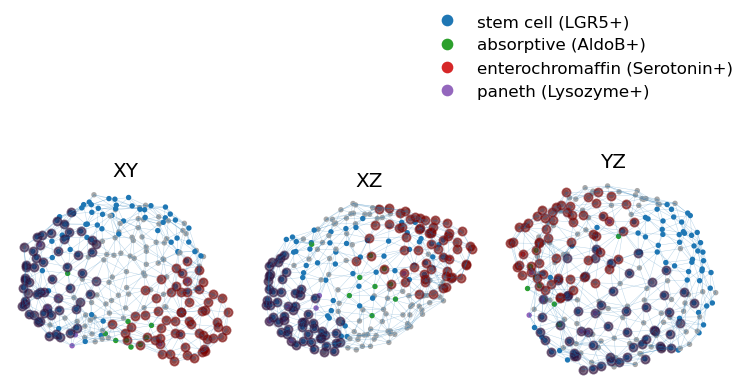

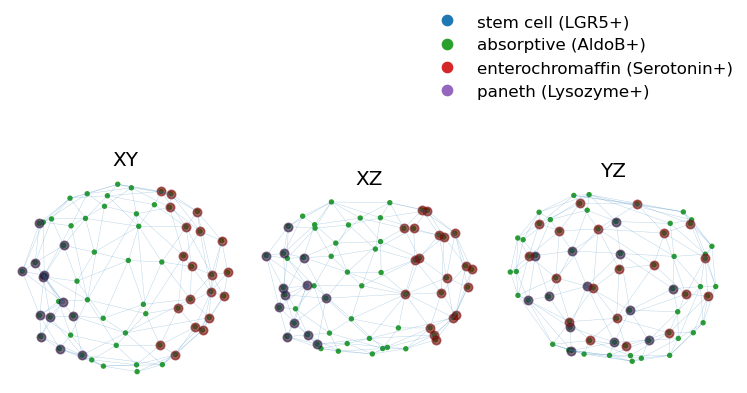

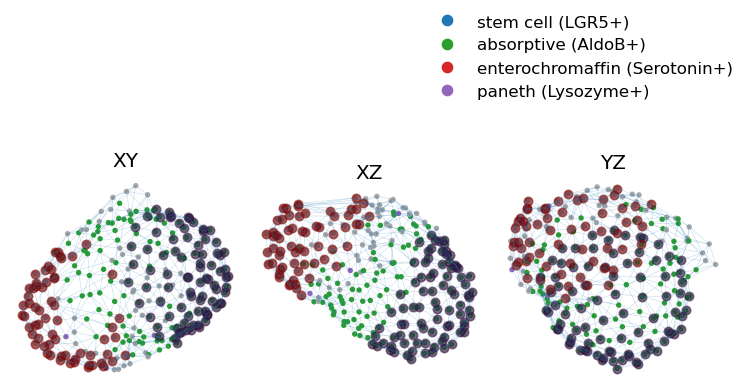

In [23]:
import matplotlib.pyplot as plt
from IPython.display import display, HTML

n_show = min(3, len(df_f))
for i in range(n_show):
    r = df_f.iloc[i]
    label_uid = r["label_uid"]

    # nice header
    display(HTML(f"<h4>{i+1}/{n_show}: {label_uid} (crypts={int(r['n_crypts'])})</h4>"))

    fig = plot_one_organoid(
        r["graph_path"],
        r["seg_path"],
        marker_map=DEFAULT_MARKER_MAP,
        backend=BACKEND,
        view=VIEW,
        node_size=NODE_SIZE,
        edge_width=EDGE_WIDTH,
        crypt_overlay_color=CRYPT_OVERLAY_COLOR,
        crypt_overlay_colorscale=CRYPT_OVERLAY_COLORSCALE,
        crypt_overlay_alpha=0.8,
        crypt_overlay_size_mult=CRYPT_OVERLAY_SIZE_MULT,
    )

    if BACKEND in ("mpl3d", "orthoprojs"):
        display(fig)
        plt.close(fig)   # prevents the “double render”
    else:
        display(fig)


## Optional widget browser

In [ ]:
if HAS_WIDGETS:
    tps = sorted(df_inspect["timepoint"].unique().tolist())
    tp_dd = widgets.Dropdown(options=tps, value=(tps[0] if tps else None), description="Timepoint:")
    nmin = widgets.IntSlider(value=0, min=0, max=int(df_inspect["n_crypts"].max() if len(df_inspect) else 0), step=1, description="Crypts ≥")
    nmax = widgets.IntSlider(value=int(df_inspect["n_crypts"].max() if len(df_inspect) else 0),
                             min=0, max=int(df_inspect["n_crypts"].max() if len(df_inspect) else 0),
                             step=1, description="Crypts ≤")
    scope_dd = widgets.Dropdown(options=["none", "organoid", "crypts"], value="none", description="Marker scope:")
    marker_txt = widgets.Text(value="LGR5", description="Marker:", placeholder="e.g. LGR5 or 0.C02...")
    backend_dd = widgets.Dropdown(options=["mpl3d", "plotly", "orthoprojs"], value=BACKEND, description="Backend:")
    show_n = widgets.IntSlider(value=1, min=1, max=12, step=1, description="#plots")
    btn = widgets.Button(description="Apply + Plot", button_style="primary")
    out = widgets.Output()

    def _apply_and_plot(_):
        with out:
            clear_output(wait=True)
            df0 = filter_table(df_inspect, timepoint=tp_dd.value, n_crypts_min=nmin.value, n_crypts_max=nmax.value, require_seg=True)
            if scope_dd.value != "none" and marker_txt.value.strip():
                df0 = filter_by_marker_presence(df0, marker_txt.value.strip(), scope=scope_dd.value)
            print(f"Filtered: {len(df0)} organoids")
            if len(df0) == 0:
                return
            n = min(show_n.value, len(df0))
            for i in range(n):
                r = df0.iloc[i]
                fig = plot_one_organoid(
                    r["graph_path"],
                    r["seg_path"],
                    marker_map=DEFAULT_MARKER_MAP,
                    backend=backend_dd.value,
                    view=VIEW,
                    node_size=NODE_SIZE,
                    edge_width=EDGE_WIDTH,
                    crypt_overlay_color=CRYPT_OVERLAY_COLOR,
                    crypt_overlay_size_mult=CRYPT_OVERLAY_SIZE_MULT,
                )
                display(fig)
                if backend_dd.value in ("mpl3d", "orthoprojs"):
                    plt.close(fig)   # <-- prevents duplicates in widget output
                print(f"{i+1}/{n}: {r['label_uid']}  (crypts={r['n_crypts']})")


    btn.on_click(_apply_and_plot)
    ui = widgets.VBox([
        widgets.HBox([tp_dd, backend_dd, show_n]),
        widgets.HBox([nmin, nmax]),
        widgets.HBox([scope_dd, marker_txt]),
        btn,
        out,
    ])
    display(ui)
else:
    print("ipywidgets not available; skipping widget UI.")